In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import os

sns.set_style("whitegrid")

os.makedirs("../reports/charts", exist_ok=True)

print("Charts folder ready.")

Charts folder ready.


In [3]:
fund_master = pd.read_csv("../data/raw/01_fund_master.csv")

nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")

aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")

sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")

category = pd.read_csv("../data/raw/05_category_inflows.csv")

folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")

performance = pd.read_csv("../data/processed/07_scheme_performance_clean.csv")

investor = pd.read_csv("../data/processed/08_investor_transactions_clean.csv")

portfolio = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

print("All files loaded successfully.")

All files loaded successfully.


In [4]:
nav['date'] = pd.to_datetime(nav['date'])

aum['date'] = pd.to_datetime(aum['date'])

sip['month'] = pd.to_datetime(sip['month'])

category['month'] = pd.to_datetime(category['month'])

folio['month'] = pd.to_datetime(folio['month'])

investor['transaction_date'] = pd.to_datetime(
    investor['transaction_date']
)

benchmark['date'] = pd.to_datetime(
    benchmark['date']
)

print("Dates converted.")

Dates converted.


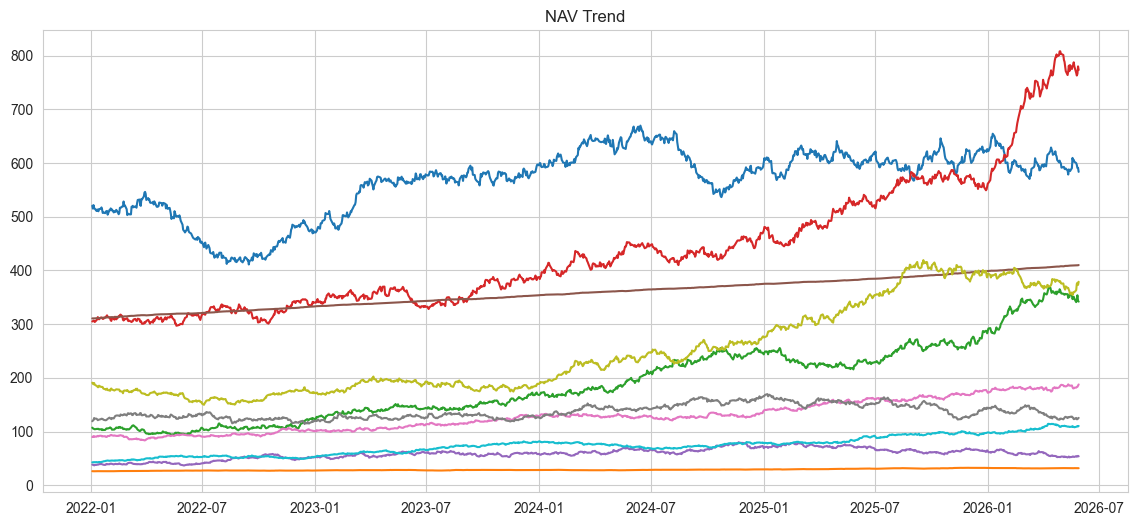

In [5]:
nav_full = pd.merge(
    nav,
    fund_master[['amfi_code','scheme_name']],
    on='amfi_code'
)

plt.figure(figsize=(14,6))

for scheme in nav_full['scheme_name'].unique()[:10]:
    
    temp = nav_full[
        nav_full['scheme_name'] == scheme
    ]
    
    plt.plot(
        temp['date'],
        temp['nav']
    )

plt.title("NAV Trend")

plt.savefig(
    "../reports/charts/01_nav_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

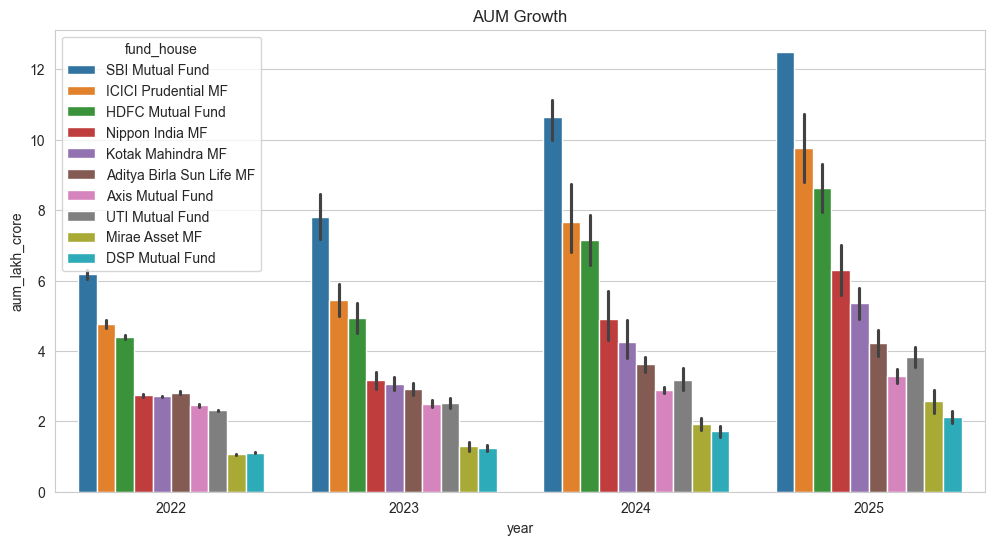

In [6]:
aum['year'] = aum['date'].dt.year

plt.figure(figsize=(12,6))

sns.barplot(
    data=aum,
    x='year',
    y='aum_lakh_crore',
    hue='fund_house'
)

plt.title("AUM Growth")

plt.savefig(
    "../reports/charts/02_aum_growth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

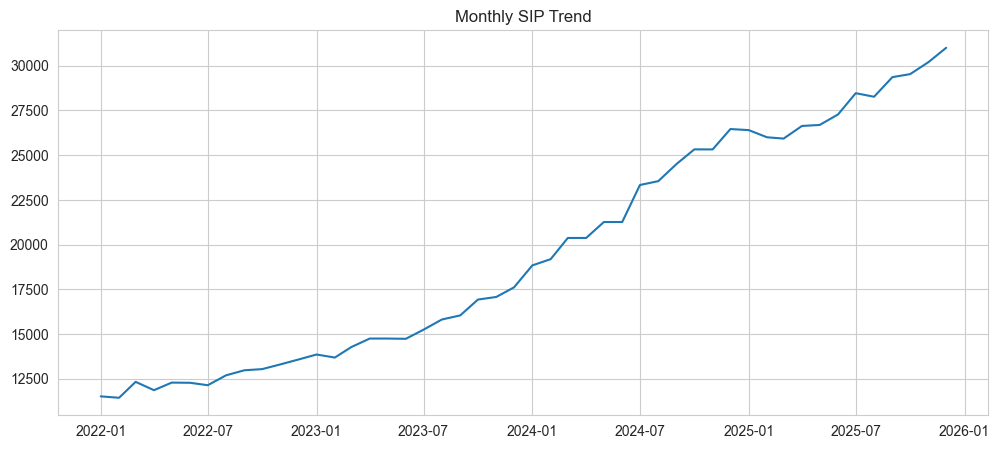

In [7]:
plt.figure(figsize=(12,5))

plt.plot(
    sip['month'],
    sip['sip_inflow_crore']
)

plt.title("Monthly SIP Trend")

plt.savefig(
    "../reports/charts/03_sip_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

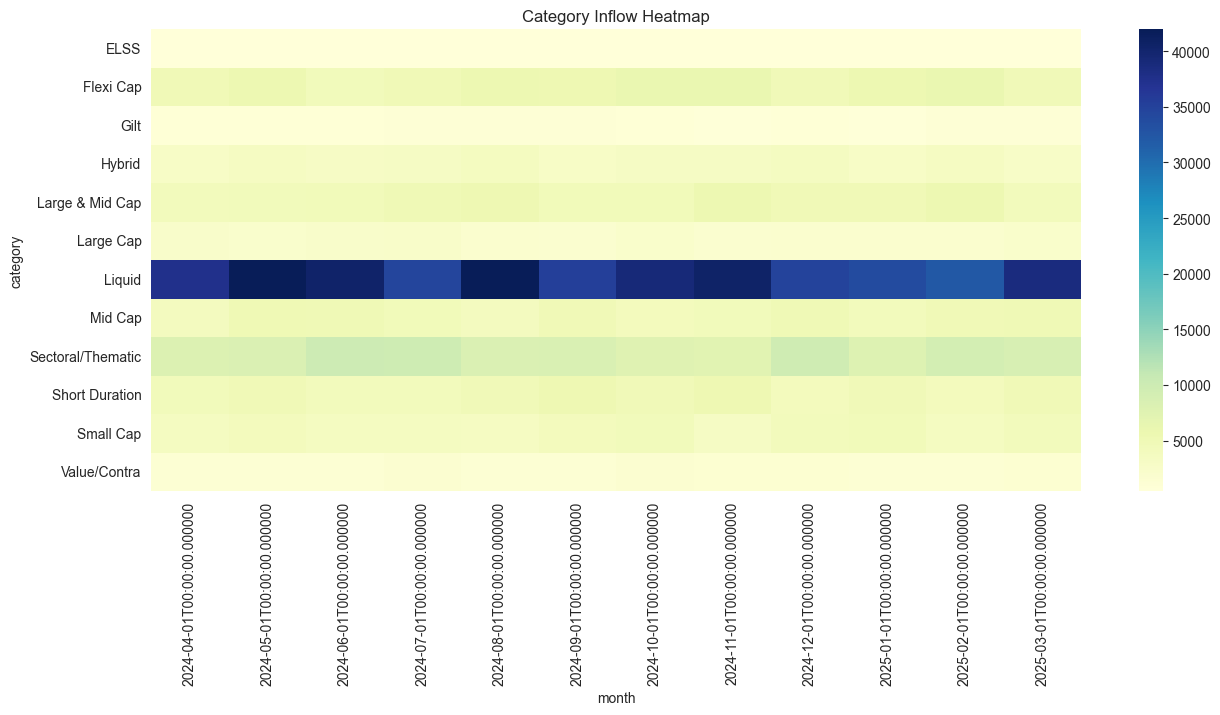

In [8]:
pivot = category.pivot_table(
    index='category',
    columns='month',
    values='net_inflow_crore'
)

plt.figure(figsize=(15,6))

sns.heatmap(
    pivot,
    cmap='YlGnBu'
)

plt.title("Category Inflow Heatmap")

plt.savefig(
    "../reports/charts/04_category_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

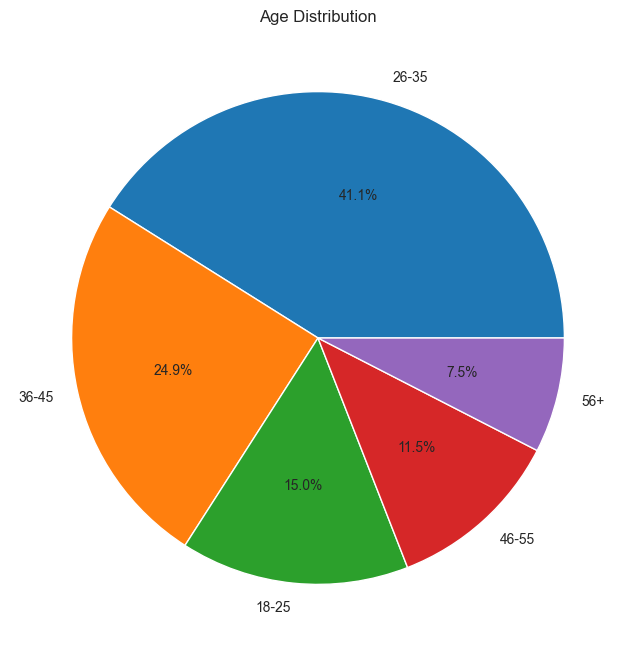

In [9]:
age = investor['age_group'].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    age,
    labels=age.index,
    autopct='%1.1f%%'
)

plt.title("Age Distribution")

plt.savefig(
    "../reports/charts/05_age_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

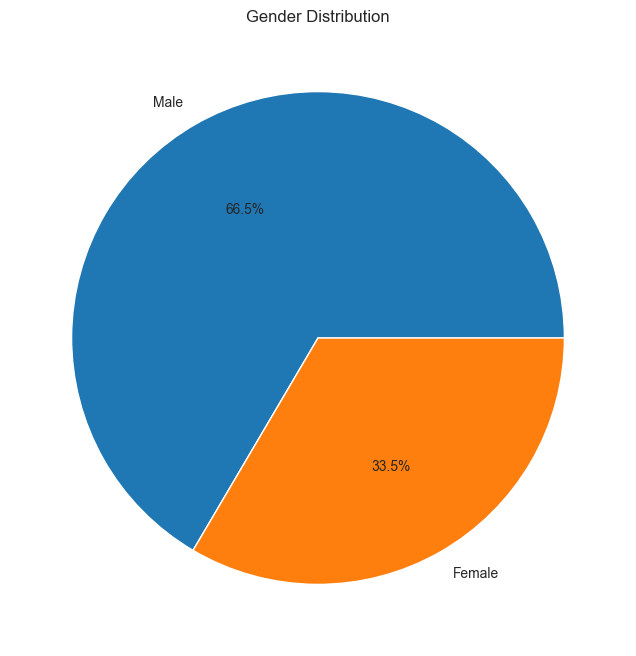

In [10]:
gender = investor['gender'].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    gender,
    labels=gender.index,
    autopct='%1.1f%%'
)

plt.title("Gender Distribution")

plt.savefig(
    "../reports/charts/06_gender_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

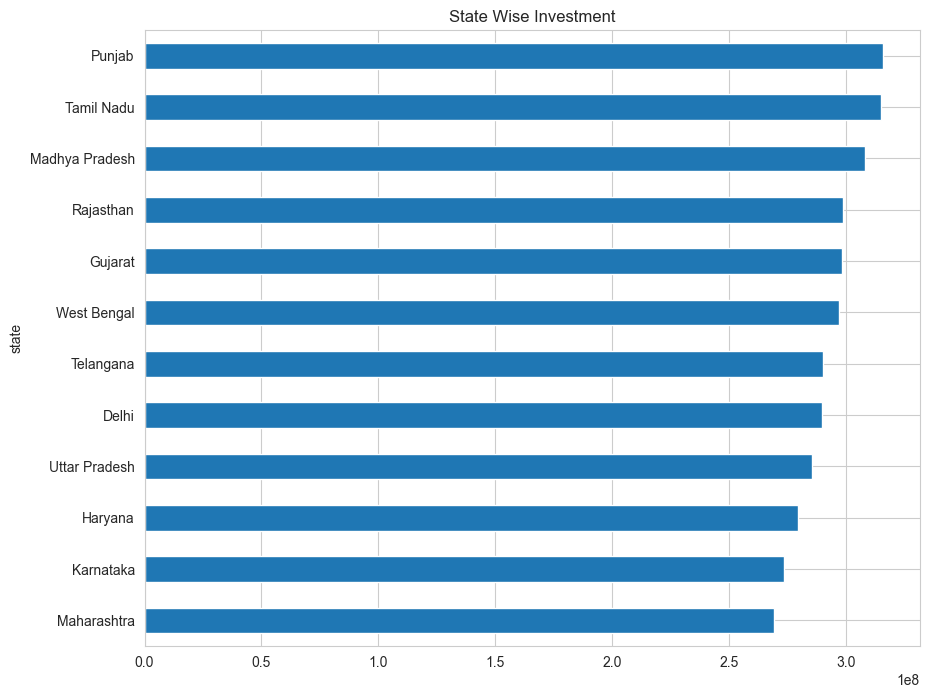

In [11]:
state = investor.groupby(
    'state'
)['amount_inr'].sum()

plt.figure(figsize=(10,8))

state.sort_values().plot(
    kind='barh'
)

plt.title("State Wise Investment")

plt.savefig(
    "../reports/charts/07_state_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

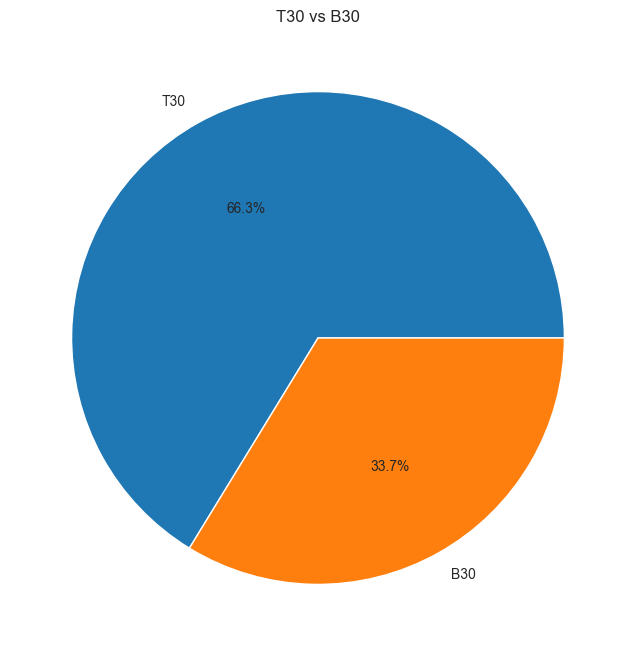

In [12]:
tier = investor['city_tier'].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    tier,
    labels=tier.index,
    autopct='%1.1f%%'
)

plt.title("T30 vs B30")

plt.savefig(
    "../reports/charts/08_t30_b30.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

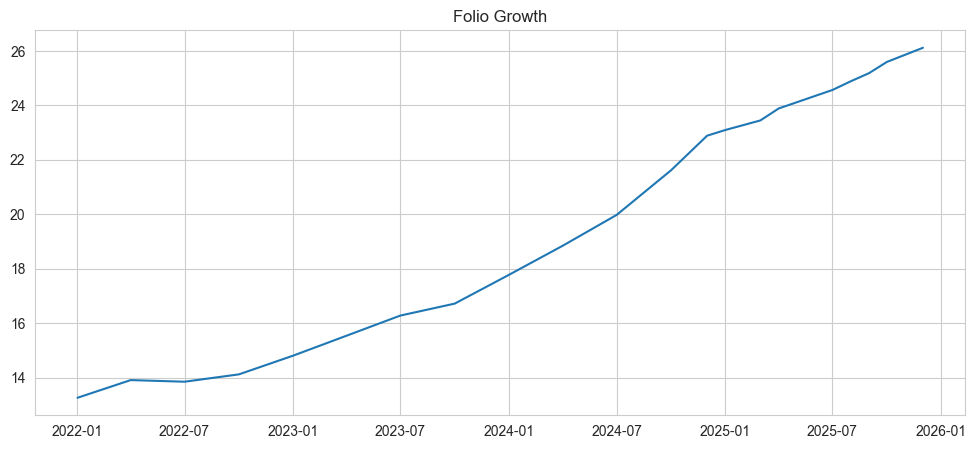

In [13]:
plt.figure(figsize=(12,5))

plt.plot(
    folio['month'],
    folio['total_folios_crore']
)

plt.title("Folio Growth")

plt.savefig(
    "../reports/charts/09_folio_growth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

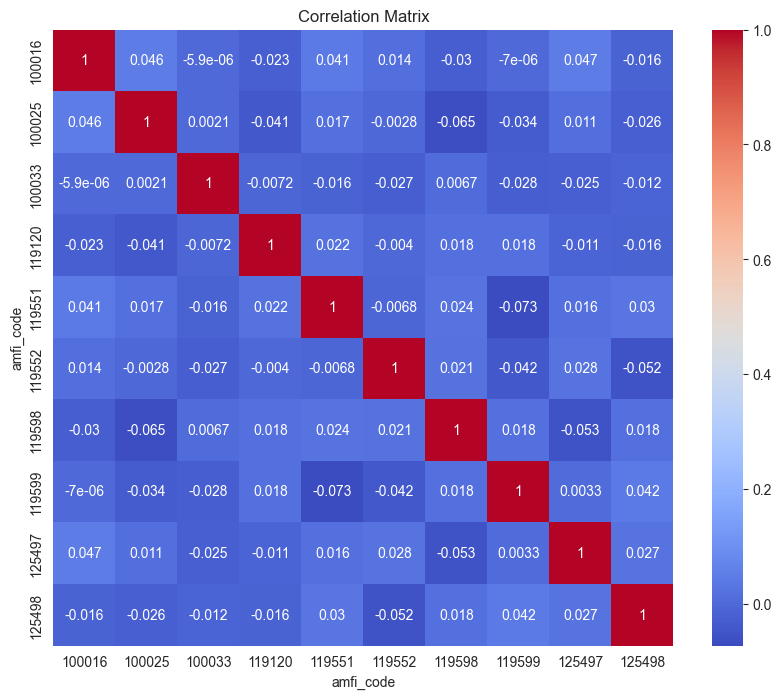

In [14]:
top10 = fund_master[
    'amfi_code'
].head(10)

corr_df = nav[
    nav['amfi_code'].isin(top10)
]

pivot = corr_df.pivot_table(
    index='date',
    columns='amfi_code',
    values='nav'
)

returns = pivot.pct_change()

corr = returns.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")

plt.savefig(
    "../reports/charts/10_correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

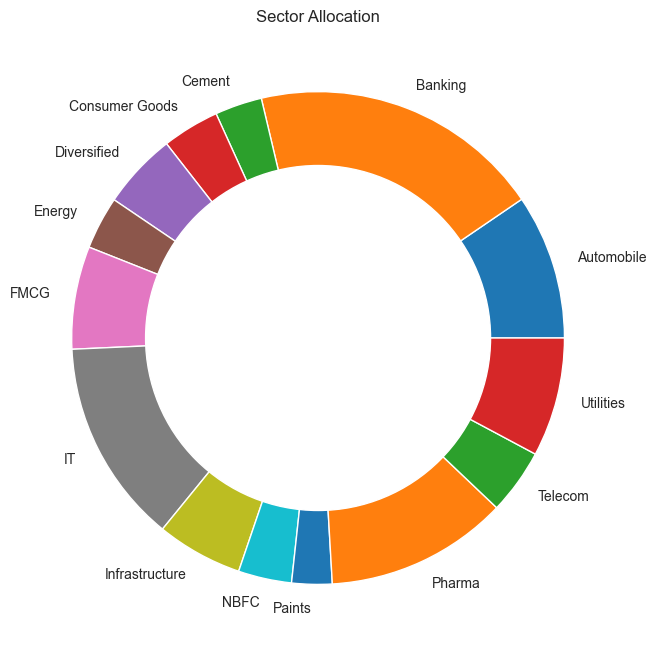

In [15]:
sector = portfolio.groupby(
    'sector'
)['weight_pct'].sum()

plt.figure(figsize=(8,8))

plt.pie(
    sector,
    labels=sector.index
)

centre = plt.Circle(
    (0,0),
    0.7,
    fc='white'
)

fig = plt.gcf()

fig.gca().add_artist(centre)

plt.title("Sector Allocation")

plt.savefig(
    "../reports/charts/11_sector_allocation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

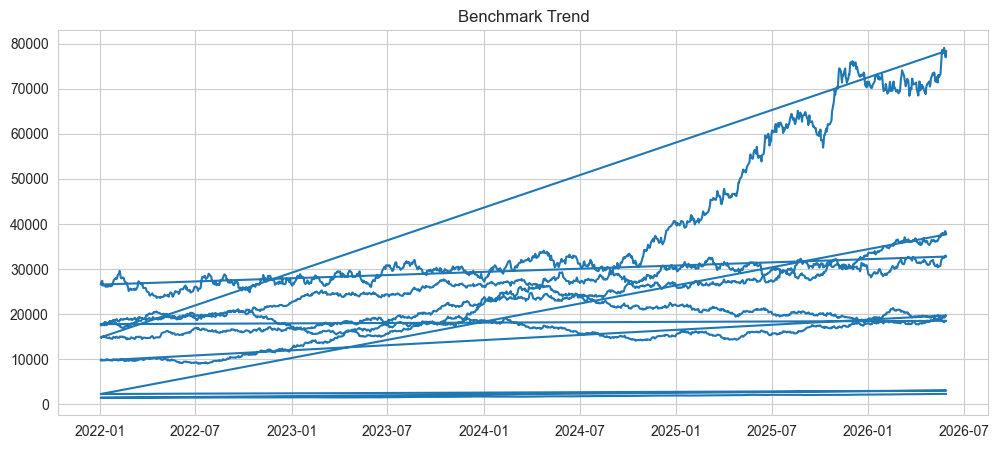

In [16]:
plt.figure(figsize=(12,5))

plt.plot(
    benchmark['date'],
    benchmark['close_value']
)

plt.title("Benchmark Trend")

plt.savefig(
    "../reports/charts/12_benchmark_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [17]:
import os

files = os.listdir("../reports/charts")

print("PNG Files Generated =", len(files))

for f in files:
    print(f)

PNG Files Generated = 12
01_nav_trend.png
02_aum_growth.png
03_sip_trend.png
04_category_heatmap.png
05_age_distribution.png
06_gender_distribution.png
07_state_distribution.png
08_t30_b30.png
09_folio_growth.png
10_correlation_matrix.png
11_sector_allocation.png
12_benchmark_trend.png


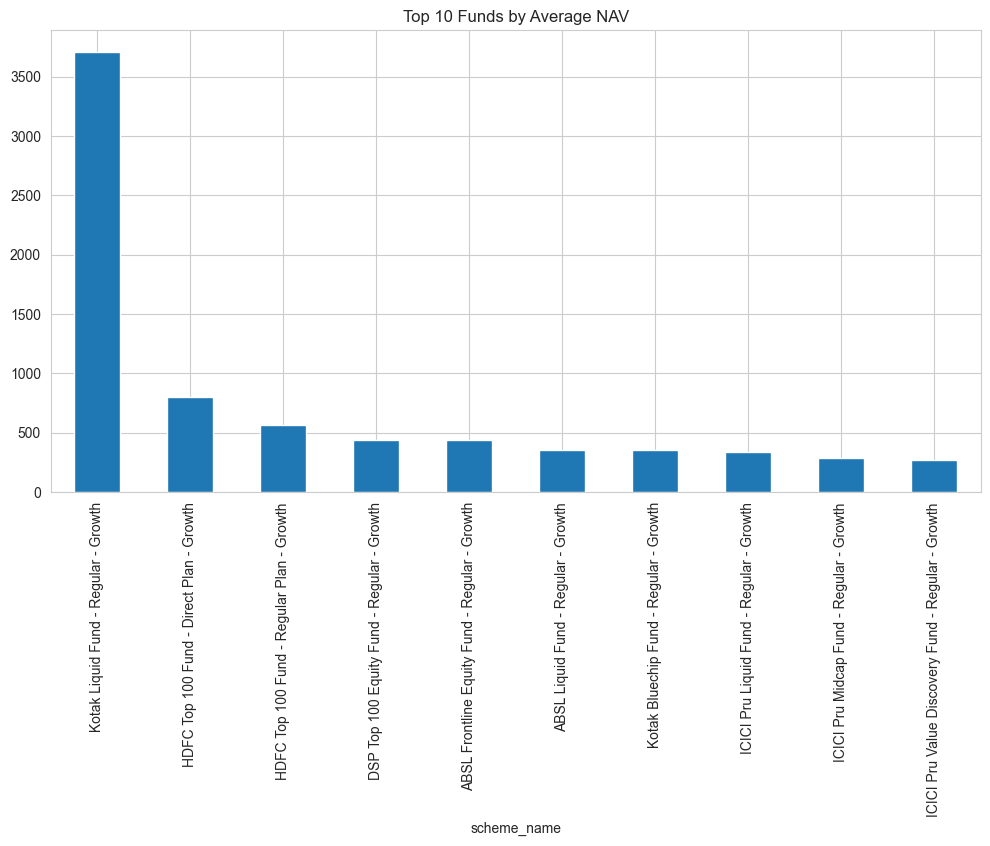

In [18]:
top_nav = nav_full.groupby(
    'scheme_name'
)['nav'].mean().sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

top_nav.plot(kind='bar')

plt.title("Top 10 Funds by Average NAV")

plt.savefig(
    "../reports/charts/13_top10_nav.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

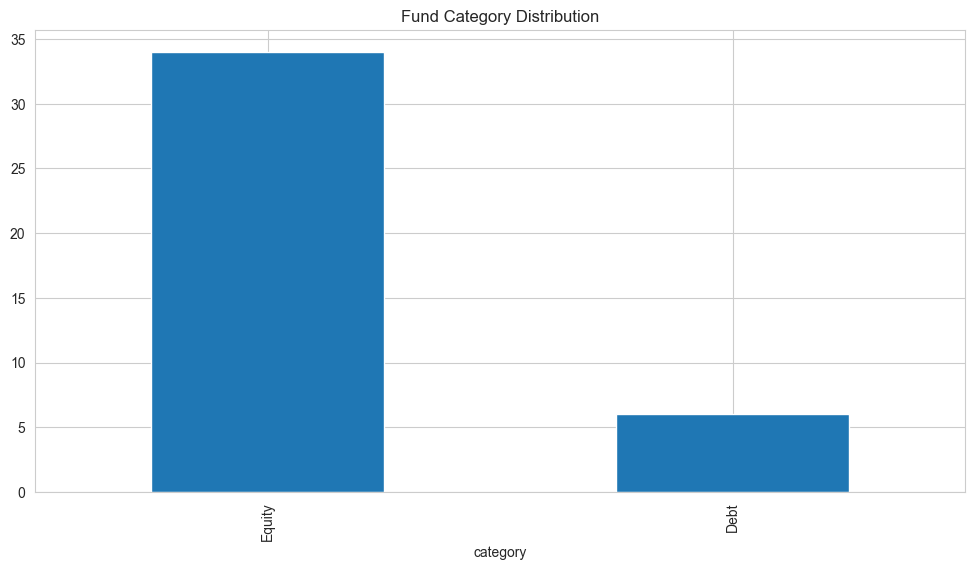

In [19]:
category_count = fund_master[
    'category'
].value_counts()

plt.figure(figsize=(12,6))

category_count.plot(
    kind='bar'
)

plt.title("Fund Category Distribution")

plt.savefig(
    "../reports/charts/14_category_distribution.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

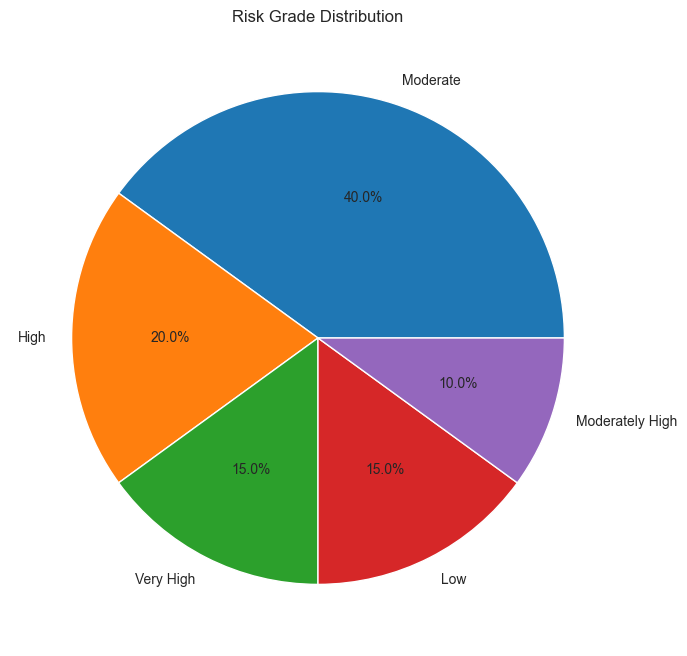

In [20]:
risk = performance[
    'risk_grade'
].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    risk,
    labels=risk.index,
    autopct='%1.1f%%'
)

plt.title("Risk Grade Distribution")

plt.savefig(
    "../reports/charts/15_risk_distribution.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

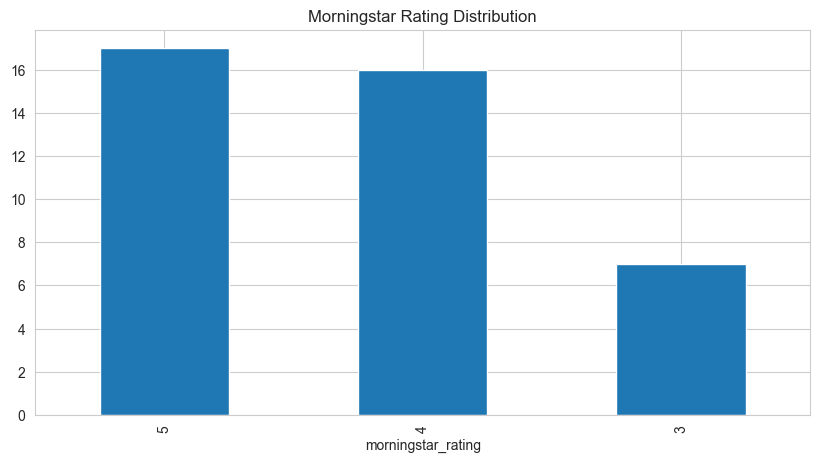

In [21]:
rating = performance[
    'morningstar_rating'
].value_counts()

plt.figure(figsize=(10,5))

rating.plot(
    kind='bar'
)

plt.title("Morningstar Rating Distribution")

plt.savefig(
    "../reports/charts/16_rating_distribution.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

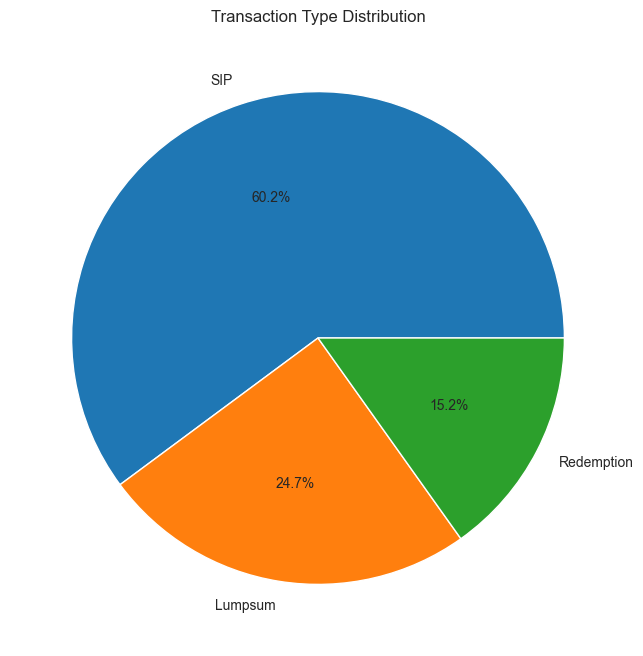

In [22]:
txn = investor[
    'transaction_type'
].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    txn,
    labels=txn.index,
    autopct='%1.1f%%'
)

plt.title("Transaction Type Distribution")

plt.savefig(
    "../reports/charts/17_transaction_distribution.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [24]:
### Finding 1
NAV values showed a consistent upward trend from 2022 to 2025.

### Finding 2
SIP inflows increased significantly over the observed period.

### Finding 3
SBI Mutual Fund maintained one of the largest AUMs.

### Finding 4
Industry folios nearly doubled between 2022 and 2025.

### Finding 5
Equity-oriented categories attracted higher inflows.

### Finding 6
The 26–35 age group formed a major investor segment.

### Finding 7
T30 cities contributed a larger share of investments.

### Finding 8
Most selected funds showed positive return correlation.

### Finding 9
Banking and Financial sectors received major allocations.

### Finding 10
Benchmark indices exhibited long-term growth despite corrections.

SyntaxError: invalid character '–' (U+2013) (2168925367.py, line 17)